**Описание проекта**

Металлургический комбинат «Стальная птица» стремится снизить производственные затраты за счёт уменьшения потребления электроэнергии на этапе обработки стали. Одним из ключевых факторов энергопотребления является контроль температуры расплава в процессе плавки.

Цель данного проекта — разработать модель машинного обучения для прогнозирования финальной температуры стального сплава на основе технологических параметров процесса. Полученная модель предполагается к использованию для имитации технологического режима и поддержки принятия производственных решений.

Обработка стали осуществляется в ковше вместимостью около 100 тонн, где расплав нагревается графитовыми электродами. В процессе плавки выполняются легирование, продувка инертным газом, перемешивание и повторные измерения температуры до достижения требуемых характеристик металла.

В работе используются данные из нескольких источников, включая информацию о нагреве электродами, подаче сыпучих и проволочных материалов, продувке газом и результатах температурных измерений. Данные представлены на уровне отдельных партий и отражают последовательные итерации технологической обработки.

Задача проекта формулируется как задача регрессии: необходимо предсказать последнее измерение температуры партии на основе доступных производственных параметров.

**План работы над проектом «Стальная птица»**

**Цель:** Построить модель машинного обучения для предсказания конечной температуры стали и продемонстрировать практическую применимость решения для повышения управляемости процесса и снижения энергозатрат.

Модель аппроксимирует тепловой баланс плавки на основе ключевых технологических параметров.

**1. Загрузка данных**

Чтение файлов с использованием конструкции `try/except`, проверка корректности загрузки, типов данных, размерностей и количества уникальных ключей. Краткий вывод о готовности данных.

**2. Исследовательский анализ данных (EDA)**

Первичный анализ каждого датасета отдельно:

- обзор структуры (`head`, `info`, `describe`);
- анализ пропусков и дубликатов;
- проверка распределений признаков и визуализация;
- выявление аномалий.

Инженерный вывод: оценка полезности признаков для моделирования.

**3. Предобработка данных**

Очистка с учетом технологического смысла:

- Удаление температурных выбросов (`< 1400 °C`).
- Исключение партий с одним замером или отсутствующим целевым признаком.
- Обработка пропусков в присадках (заполнение нулями).
- Удаление некорректных значений в электроэнергии (отрицательная реактивная мощность).
- Проверка временной логики (исключение событий «из будущего» относительно финального замера).

**4. Подготовка признаков (Feature Engineering)**

Расчет признаков, отражающих физику процесса:

- выделение начальной (`first_temp`) и конечной температуры (`target`);
- агрегация энергии и длительности нагрева;
- Smart Aggregation присадок: разделение на группы «маркеры нагрева» (положительное влияние) и «охладители» (отрицательное влияние);
- расчет интенсивности нагрева (`energy_rate`) и полных теплопотерь (`process_duration`);
- генерация электрических параметров: полная мощность и коэффициент мощности (`cos φ`).

**5. Объединение данных**

Формирование единого аналитического датасета на уровне партии (`Inner Join` по ключу `key`). Строгая проверка причинности признаков и финальный контроль отсутствия пропусков.

**6. Подготовка данных к моделированию**

- Удаление технических признаков (`key`, временные метки).
- Разделение на обучающую и тестовую выборки (`test_size = 0.25`, `random_state = 30226`).
- Масштабирование признаков (`StandardScaler`) внутри Pipeline (критично для Ridge Regression).

**7. Обучение моделей**

Сравнение нескольких алгоритмов:

- Baseline (`DummyRegressor`) — уровень «наивного» прогноза.
- Ridge Regression — линейная модель с регуляризацией.
- Random Forest — ансамбль решающих деревьев.
- CatBoost — градиентный бустинг (основной кандидат на высокую точность).

Подбор гиперпараметров через `RandomizedSearchCV` с кросс-валидацией.

**8. Анализ результатов**

- Сравнение моделей по метрике MAE.
- Выбор лучшей модели и проверка на тестовой выборке (цель: `MAE ≤ 6.8`).
- Анализ важности признаков (`feature_importance`): оценка вклада начальной температуры, энергии и присадок в прогноз.
- Интерпретация результатов с точки зрения теплового баланса.

**9. Итоговый отчет**

Сводка по проекту:

- ход работы и ключевые технические решения (очистка утечек, Smart Aggregation);
- параметры и точность финальной модели.

**Бизнес-рекомендации:** как использовать модель для контроля перегрева и экономии электроэнергии на комбинате.

**Импорт библиотек**

In [96]:
# Работа с данными
import pandas as pd
import numpy as np
import os

# Отображение таблиц в ноутбуке
from IPython.display import display

# Визуализация
import matplotlib.pyplot as plt
import seaborn as sns

# Разделение данных и валидация
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    RandomizedSearchCV,
    KFold
)
from sklearn.model_selection import cross_val_score, KFold

# Базовые модели
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

# Pipeline и масштабирование
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Метрики
from sklearn.metrics import mean_absolute_error

# Градиентный бустинг
from catboost import CatBoostRegressor

from pathlib import Path
import pandas as pd

# 1. Загрузка данных и первичный осмотр

Заданы константы проекта, включая random_state, пути к данным и словарь источников. Реализована загрузка файлов с автоматической проверкой доступности локального и серверного путей.

In [97]:
from pathlib import Path
import pandas as pd

# Константы проекта
RANDOM_STATE = 30226

# Базовая директория
BASE_DIR = Path().resolve()

# фикс для запуска из notebooks
if BASE_DIR.name == "notebooks":
    BASE_DIR = BASE_DIR.parent

# Пути к данным
RAW_DATA_DIR = BASE_DIR / "datasets" / "raw"

# Имена файлов по источникам
FILES = {
    "data_arc": "data_arc_new.csv",
    "data_bulk": "data_bulk_new.csv",
    "data_bulk_time": "data_bulk_time_new.csv",
    "data_gas": "data_gas_new.csv",
    "data_temp": "data_temp_new.csv",
    "data_wire": "data_wire_new.csv",
    "data_wire_time": "data_wire_time_new.csv"
}

# Загруженные датафреймы
data = {}

print("Загрузка данных")

for name, filename in FILES.items():
    path = RAW_DATA_DIR / filename

    if not path.exists():
        raise FileNotFoundError(f"{name}: файл не найден → {path}")

    try:
        df = pd.read_csv(path)
        data[name] = df
        print(f"{name}: загружен ({df.shape})")

    except Exception as e:
        raise RuntimeError(f"{name}: ошибка загрузки — {e}")

Загрузка данных
data_arc: загружен ((14876, 5))
data_bulk: загружен ((3129, 16))
data_bulk_time: загружен ((3129, 16))
data_gas: загружен ((3239, 2))
data_temp: загружен ((18092, 3))
data_wire: загружен ((3081, 10))
data_wire_time: загружен ((3081, 10))


Выполнена базовая валидация загруженных датасетов: проверены размеры таблиц и наличие ключевого поля key, используемого для последующего объединения. Дополнительно оценено количество уникальных партий, что позволяет заранее выявить структурные проблемы и убедиться в корректности источников данных перед этапом EDA и merge.

In [98]:
# 2. Базовая проверка датасетов: размеры и наличие ключа

print("\nБазовая проверка датасетов")
print(f"{'Датасет':<20} | {'Строк':<8} | {'Колонок':<8} | {'Уникальных key':<15}")
print("-" * 65)

for name, df in data.items():
    n_rows, n_cols = df.shape

    # Проверяем наличие столбца key
    if 'key' in df.columns:
        n_keys = df['key'].nunique()
    else:
        n_keys = "нет key"
        
    print(f"{name:<20} | {n_rows:<8} | {n_cols:<8} | {n_keys:<15}")


Базовая проверка датасетов
Датасет              | Строк    | Колонок  | Уникальных key 
-----------------------------------------------------------------
data_arc             | 14876    | 5        | 3214           
data_bulk            | 3129     | 16       | 3129           
data_bulk_time       | 3129     | 16       | 3129           
data_gas             | 3239     | 2        | 3239           
data_temp            | 18092    | 3        | 3216           
data_wire            | 3081     | 10       | 3081           
data_wire_time       | 3081     | 10       | 3081           


**Краткий анализ:**
Датасеты имеют различное количество партий, это требует аккуратного объединения по пересечению ключей. Таблицы bulk, wire и их временные аналоги согласованы по размеру, что указывает на целостность источников. Наибольшее число партий наблюдается в data_gas, тогда как в data_wire и data_bulk их меньше  при merge часть плавок будет потеряна, поэтому использовать объединение по общим ключам.

# 2. Исследовательский анализ (EDA) и предобработка исходных таблиц

Реализована универсальная функция первичного EDA, позволяющая гибко выполнять ключевые проверки датасета: структуру, статистику, пропуски, дубликаты и состояние ключевого поля. Параметризация вывода снижает шум в ноутбуке и делает анализ воспроизводимым. Функция формирует стандартизированный подход к проверке источников перед предобработкой и генерацией признаков.

In [99]:
# Универсальная функция для быстрого первичного анализа датасета. 
def basic_eda(
    df,
    name="dataset",
    show_head=True,
    show_info=True,
    show_describe=True,
    show_missing=True,
    show_duplicates=True,
    show_key_stats=True
):
    
    print("\nEDA:", name)
    print("-" * 30)

    # Первые строки 
    if show_head:
        print("\nПервые строки:")
        display(df.head())

    # Типы данных и заполненность колонок
    if show_info:
        print("\nСтруктура:")
        df.info()

    # Базовая статистика по числовым признакам
    if show_describe:
        print("\nСтатистика:")
        display(df.describe())

    # Проверка пропусков
    if show_missing:
        print("\nПропуски:")
        missing = df.isna().sum()
        missing = missing[missing > 0].sort_values(ascending=False)

        if len(missing) == 0:
            print("не обнаружены")
        else:
            display(missing.to_frame("кол-во"))

    # Полные дубликаты строк
    if show_duplicates:
        print("\nДубликаты строк:")
        print(df.duplicated().sum())

    # Контроль ключа 
    if show_key_stats and 'key' in df.columns:
        print("\nКлюч:")
        print("уникальных key:", df['key'].nunique())

    print("\n")

In [100]:
basic_eda(data['data_temp'], "TEMPERATURE")


EDA: TEMPERATURE
------------------------------

Первые строки:


,key,Время замера,Температура
0,1,2019-05-03 11:02:04,1571.0
1,1,2019-05-03 11:07:18,1604.0
2,1,2019-05-03 11:11:34,1618.0
3,1,2019-05-03 11:18:04,1601.0
4,1,2019-05-03 11:25:59,1606.0



Структура:
<class 'pandas.DataFrame'>
RangeIndex: 18092 entries, 0 to 18091
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   key           18092 non-null  int64  
 1   Время замера  18092 non-null  str    
 2   Температура   14665 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 424.2 KB

Статистика:


,key,Температура
count,18092.000000,14665.000000
mean,1616.460977,1590.722741
std,934.641385,20.394381
min,1.000000,1191.000000
25%,807.750000,1580.000000
50%,1618.000000,1590.000000
75%,2429.000000,1599.000000
max,3241.000000,1705.000000



Пропуски:


,кол-во
Температура,3427



Дубликаты строк:
0

Ключ:
уникальных key: 3216




**Краткий анализ:**.Таблица содержит 18 092 измерения температуры для 3 216 партий; около 19% значений отсутствуют  важно проверить. Температуры в основном сосредоточены около 1590 °C, а минимум 1191 °C выглядит аномальным и потребует фильтрации. Дубликатов нет, несколько измерений на партию соответствуют логике поэтапного нагрева стали.

In [101]:
basic_eda(data['data_arc'], "ARC (Power)")


EDA: ARC (Power)
------------------------------

Первые строки:


,key,Начало нагрева дугой,Конец нагрева дугой,Активная мощность,Реактивная мощность
0,1,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253
1,1,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438
2,1,2019-05-03 11:11:44,2019-05-03 11:14:36,0.580313,0.430460
3,1,2019-05-03 11:18:14,2019-05-03 11:24:19,0.518496,0.379979
4,1,2019-05-03 11:26:09,2019-05-03 11:28:37,0.867133,0.643691



Структура:
<class 'pandas.DataFrame'>
RangeIndex: 14876 entries, 0 to 14875
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   key                   14876 non-null  int64  
 1   Начало нагрева дугой  14876 non-null  str    
 2   Конец нагрева дугой   14876 non-null  str    
 3   Активная мощность     14876 non-null  float64
 4   Реактивная мощность   14876 non-null  float64
dtypes: float64(2), int64(1), str(2)
memory usage: 581.2 KB

Статистика:


,key,Активная мощность,Реактивная мощность
count,14876.000000,14876.000000,14876.000000
mean,1615.220422,0.662752,0.438986
std,934.571502,0.258885,5.873485
min,1.000000,0.223120,-715.479924
25%,806.000000,0.467115,0.337175
50%,1617.000000,0.599587,0.441639
75%,2429.000000,0.830070,0.608201
max,3241.000000,1.463773,1.270284



Пропуски:
не обнаружены

Дубликаты строк:
0

Ключ:
уникальных key: 3214




Определяются партии, в которых обнаружены некорректные значения реактивной мощности (≤ 0), после чего все записи, относящиеся к этим ключам, удаляются из датасета data_arc.

In [102]:
# Очистка аномалий: удаляем партии с отрицательной реактивной мощностью
# 1. Находим ключи
bad_keys = data['data_arc'].loc[data['data_arc']['Реактивная мощность'] <= 0, 'key'].unique()

# 2. Фильтруем датасет
data['data_arc'] = data['data_arc'][~data['data_arc']['key'].isin(bad_keys)]

# Проверка
print(f"Количество строк <= 0: {(data['data_arc']['Реактивная мощность'] <= 0).sum()}")

Количество строк <= 0: 0


**Краткий анализ:**.Таблица содержит 14 876 записей нагрева без пропусков и дубликатов, что говорит о хорошем качестве данных. Активная мощность распределена стабильно, тогда как в реактивной мощности есть экстремально отрицательное значение (-715), вероятно являющееся аномалией и требующее проверки или фильтрации - очищено. Несколько записей на партию отражают повторные циклы нагрева.

In [103]:
basic_eda(data['data_bulk'], "BULK")


EDA: BULK
------------------------------

Первые строки:


,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
0,1,NaN,NaN,NaN,43.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,206.0,NaN,150.0,154.0
1,2,NaN,NaN,NaN,73.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,206.0,NaN,149.0,154.0
2,3,NaN,NaN,NaN,34.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,205.0,NaN,152.0,153.0
3,4,NaN,NaN,NaN,81.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,207.0,NaN,153.0,154.0
4,5,NaN,NaN,NaN,78.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,203.0,NaN,151.0,152.0



Структура:
<class 'pandas.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   key      3129 non-null   int64  
 1   Bulk 1   252 non-null    float64
 2   Bulk 2   22 non-null     float64
 3   Bulk 3   1298 non-null   float64
 4   Bulk 4   1014 non-null   float64
 5   Bulk 5   77 non-null     float64
 6   Bulk 6   576 non-null    float64
 7   Bulk 7   25 non-null     float64
 8   Bulk 8   1 non-null      float64
 9   Bulk 9   19 non-null     float64
 10  Bulk 10  176 non-null    float64
 11  Bulk 11  177 non-null    float64
 12  Bulk 12  2450 non-null   float64
 13  Bulk 13  18 non-null     float64
 14  Bulk 14  2806 non-null   float64
 15  Bulk 15  2248 non-null   float64
dtypes: float64(15), int64(1)
memory usage: 391.3 KB

Статистика:


,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
count,3129.000000,252.000000,22.000000,1298.000000,1014.000000,77.000000,576.000000,25.000000,1.0,19.000000,176.000000,177.000000,2450.000000,18.000000,2806.000000,2248.000000
mean,1624.383509,39.242063,253.045455,113.879045,104.394477,107.025974,118.925347,305.600000,49.0,76.315789,83.284091,76.819209,260.471020,181.111111,170.284747,160.513345
std,933.337642,18.277654,21.180578,75.483494,48.184126,81.790646,72.057776,191.022904,NaN,21.720581,26.060347,59.655365,120.649269,46.088009,65.868652,51.765319
min,1.000000,10.000000,228.000000,6.000000,12.000000,11.000000,17.000000,47.000000,49.0,63.000000,24.000000,8.000000,53.000000,151.000000,16.000000,1.000000
25%,816.000000,27.000000,242.000000,58.000000,72.000000,70.000000,69.750000,155.000000,49.0,66.000000,64.000000,25.000000,204.000000,153.250000,119.000000,105.000000
50%,1622.000000,31.000000,251.500000,97.500000,102.000000,86.000000,100.000000,298.000000,49.0,68.000000,86.500000,64.000000,208.000000,155.500000,151.000000,160.000000
75%,2431.000000,46.000000,257.750000,152.000000,133.000000,132.000000,157.000000,406.000000,49.0,70.500000,102.000000,106.000000,316.000000,203.500000,205.750000,205.000000
max,3241.000000,185.000000,325.000000,454.000000,281.000000,603.000000,503.000000,772.000000,49.0,147.000000,159.000000,313.000000,1849.000000,305.000000,636.000000,405.000000



Пропуски:


,кол-во
Bulk 8,3128
Bulk 13,3111
Bulk 9,3110
Bulk 2,3107
Bulk 7,3104
Bulk 5,3052
Bulk 10,2953
Bulk 11,2952
Bulk 1,2877
Bulk 6,2553



Дубликаты строк:
0

Ключ:
уникальных key: 3129




**Краткий анализ:**.Таблица содержит данные о подаче сыпучих материалов на уровне партий, дубликатов нет каждая плавка представлена одной строкой. Во многих колонках большое количество пропусков, что логично для редких добавок; отсутствие значения, означает, что материал не подавался  такие пропуски можно заменить на 0. Основной вклад дают Bulk 12, Bulk 14 и Bulk 15 (наименьшая доля пропусков), тогда как признаки с почти пустыми колонками стоит рассмотреть на предмет удаления или последующей агрегации.

In [104]:
basic_eda(data['data_bulk_time'], "BULK TIME")


EDA: BULK TIME
------------------------------

Первые строки:


,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
0,1,NaN,NaN,NaN,2019-05-03 11:28:48,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-03 11:24:31,NaN,2019-05-03 11:14:50,2019-05-03 11:10:43
1,2,NaN,NaN,NaN,2019-05-03 11:36:50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-03 11:53:30,NaN,2019-05-03 11:48:37,2019-05-03 11:44:39
2,3,NaN,NaN,NaN,2019-05-03 12:32:39,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-03 12:27:13,NaN,2019-05-03 12:21:01,2019-05-03 12:16:16
3,4,NaN,NaN,NaN,2019-05-03 12:43:22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-03 12:58:00,NaN,2019-05-03 12:51:11,2019-05-03 12:46:36
4,5,NaN,NaN,NaN,2019-05-03 13:30:47,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-03 13:30:47,NaN,2019-05-03 13:34:12,2019-05-03 13:30:47



Структура:
<class 'pandas.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   key      3129 non-null   int64
 1   Bulk 1   252 non-null    str  
 2   Bulk 2   22 non-null     str  
 3   Bulk 3   1298 non-null   str  
 4   Bulk 4   1014 non-null   str  
 5   Bulk 5   77 non-null     str  
 6   Bulk 6   576 non-null    str  
 7   Bulk 7   25 non-null     str  
 8   Bulk 8   1 non-null      str  
 9   Bulk 9   19 non-null     str  
 10  Bulk 10  176 non-null    str  
 11  Bulk 11  177 non-null    str  
 12  Bulk 12  2450 non-null   str  
 13  Bulk 13  18 non-null     str  
 14  Bulk 14  2806 non-null   str  
 15  Bulk 15  2248 non-null   str  
dtypes: int64(1), str(15)
memory usage: 391.3 KB

Статистика:


,key
count,3129.000000
mean,1624.383509
std,933.337642
min,1.000000
25%,816.000000
50%,1622.000000
75%,2431.000000
max,3241.000000



Пропуски:


,кол-во
Bulk 8,3128
Bulk 13,3111
Bulk 9,3110
Bulk 2,3107
Bulk 7,3104
Bulk 5,3052
Bulk 10,2953
Bulk 11,2952
Bulk 1,2877
Bulk 6,2553



Дубликаты строк:
0

Ключ:
уникальных key: 3129




**Краткий анализ:**. Таблица содержит время подачи материалов и повторяет структуру BULK. Большое количество пропусков связано с тем, что многие добавки используются редко  это особенность технологического процесса. Временные признаки представлены в формате object, поэтому их необходимо привести к datetime перед расчетом технологических интервалов; признаки с почти пустыми колонками можно не использовать отдельно и рассмотреть для агрегации.

In [105]:
basic_eda(data['data_wire'], "WIRE")


EDA: WIRE
------------------------------

Первые строки:


,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
0,1,60.059998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,96.052315,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,91.160157,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,89.063515,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,89.238236,9.11456,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Структура:
<class 'pandas.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   key     3081 non-null   int64  
 1   Wire 1  3055 non-null   float64
 2   Wire 2  1079 non-null   float64
 3   Wire 3  63 non-null     float64
 4   Wire 4  14 non-null     float64
 5   Wire 5  1 non-null      float64
 6   Wire 6  73 non-null     float64
 7   Wire 7  11 non-null     float64
 8   Wire 8  19 non-null     float64
 9   Wire 9  29 non-null     float64
dtypes: float64(9), int64(1)
memory usage: 240.8 KB

Статистика:


,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
count,3081.000000,3055.000000,1079.000000,63.000000,14.000000,1.000,73.000000,11.000000,19.000000,29.000000
mean,1623.426485,100.895853,50.577323,189.482681,57.442841,15.132,48.016974,10.039007,53.625193,34.155752
std,932.996726,42.012518,39.320216,99.513444,28.824667,NaN,33.919845,8.610584,16.881728,19.931616
min,1.000000,1.918800,0.030160,0.144144,24.148801,15.132,0.034320,0.234208,45.076721,4.622800
25%,823.000000,72.115684,20.193680,95.135044,40.807002,15.132,25.053600,6.762756,46.094879,22.058401
50%,1619.000000,100.158234,40.142956,235.194977,45.234282,15.132,42.076324,9.017009,46.279999,30.066399
75%,2434.000000,126.060483,70.227558,276.252014,76.124619,15.132,64.212723,11.886057,48.089603,43.862003
max,3241.000000,330.314424,282.780152,385.008668,113.231044,15.132,180.454575,32.847674,102.762401,90.053604



Пропуски:


,кол-во
Wire 5,3080
Wire 7,3070
Wire 4,3067
Wire 8,3062
Wire 9,3052
Wire 3,3018
Wire 6,3008
Wire 2,2002
Wire 1,26



Дубликаты строк:
0

Ключ:
уникальных key: 3081




**Краткий анализ:**. Таблица содержит объёмы подачи материалов на уровне партий, дубликатов нет. Основной вклад даёт Wire 1 (почти без пропусков), тогда как остальные признаки  отсутствие значений, означает отсутствие подачи и может быть заменено на 0. Колонки с единичными наблюдениями не несут стабильного сигнала и логично рассмотреть их для удаления или агрегации.

In [106]:
basic_eda(data['data_wire_time'], "WIRE TIME")


EDA: WIRE TIME
------------------------------

Первые строки:


,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
0,1,2019-05-03 11:06:19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2019-05-03 11:36:50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,2019-05-03 12:11:46,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,2019-05-03 12:43:22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,2019-05-03 13:20:44,2019-05-03 13:15:34,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Структура:
<class 'pandas.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   key     3081 non-null   int64
 1   Wire 1  3055 non-null   str  
 2   Wire 2  1079 non-null   str  
 3   Wire 3  63 non-null     str  
 4   Wire 4  14 non-null     str  
 5   Wire 5  1 non-null      str  
 6   Wire 6  73 non-null     str  
 7   Wire 7  11 non-null     str  
 8   Wire 8  19 non-null     str  
 9   Wire 9  29 non-null     str  
dtypes: int64(1), str(9)
memory usage: 240.8 KB

Статистика:


,key
count,3081.000000
mean,1623.426485
std,932.996726
min,1.000000
25%,823.000000
50%,1619.000000
75%,2434.000000
max,3241.000000



Пропуски:


,кол-во
Wire 5,3080
Wire 7,3070
Wire 4,3067
Wire 8,3062
Wire 9,3052
Wire 3,3018
Wire 6,3008
Wire 2,2002
Wire 1,26



Дубликаты строк:
0

Ключ:
уникальных key: 3081




**Краткий анализ:**. Таблица содержит время подачи проволочных материалов и согласована с WIRE по количеству партий. Большое число пропусков связано с редким использованием отдельных материалов. Временные признаки представлены в формате object, поэтому их необходимо привести к datetime перед анализом; разреженные колонки целесообразно агрегировать вместо использования по отдельности.

In [107]:
basic_eda(data['data_gas'], "GAS")


EDA: GAS
------------------------------

Первые строки:


,key,Газ 1
0,1,29.749986
1,2,12.555561
2,3,28.554793
3,4,18.841219
4,5,5.413692



Структура:
<class 'pandas.DataFrame'>
RangeIndex: 3239 entries, 0 to 3238
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   key     3239 non-null   int64  
 1   Газ 1   3239 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 50.7 KB

Статистика:


,key,Газ 1
count,3239.000000,3239.000000
mean,1621.861377,11.002062
std,935.386334,6.220327
min,1.000000,0.008399
25%,812.500000,7.043089
50%,1622.000000,9.836267
75%,2431.500000,13.769915
max,3241.000000,77.995040



Пропуски:
не обнаружены

Дубликаты строк:
0

Ключ:
уникальных key: 3239




**Краткий анализ:**. Таблица содержит объём продувки газом на уровне партий, пропусков и дубликатов нет  данные выглядят полными. Распределение значений без явных аномалий, признак можно использовать в модели без дополнительной очистки. Поскольку каждая партия представлена одной строкой, агрегирование не требуется, признак готов к объединению с другими таблицами.

Реализована функция для быстрого **анализа распределения признаков**, включающая описательную статистику, квантили и гистограмму.позволяет оперативно выявлять выбросы, асимметрию и особенности распределения перед очисткой и генерацией признаков. Функция стандартизирует проверку числовых переменных и упрощает принятие решений о предобработке.

In [108]:
# Функция для быстрого анализа распределения признака:
# базовую статистику, квантили и гистограмму.
def feature_distribution(
    series,
    name="feature",
    bins=50,
    show_table=True,
    show_plot=True
):
    
    print("\nРаспределение:", name)
    print("-" * 30)

    # Табличная сводка
    if show_table:
        display(series.describe().to_frame("значение"))

        quantiles = series.quantile([
            0.01, 0.05, 0.25, 0.5,
            0.75, 0.95, 0.99
        ])
        display(quantiles.to_frame("квантиль"))

    # Гистограмма
    if show_plot:
        plt.figure(figsize=(8, 4))
        plt.hist(series, bins=bins)
        plt.title(f"Распределение — {name}")
        plt.show()


Распределение: Temperature
------------------------------


,значение
count,14665.000000
mean,1590.722741
std,20.394381
min,1191.000000
25%,1580.000000
50%,1590.000000
75%,1599.000000
max,1705.000000


,квантиль
0.01,1545.0
0.05,1562.0
0.25,1580.0
0.50,1590.0
0.75,1599.0
0.95,1623.0
0.99,1651.0


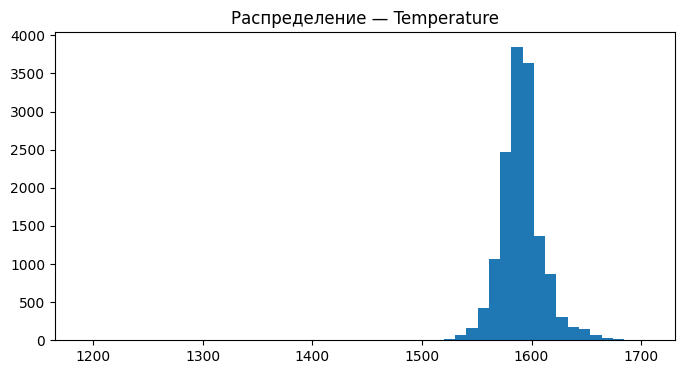

In [109]:
feature_distribution(
    data['data_temp']['Температура'],
    "Temperature"
)

**Краткий анализ:**. Температуры сосредоточены в узком технологическом диапазоне около 1590 °C, что указывает на контролируемый процесс нагрева. Нижняя граница (1191 °C) сильно выбивается из распределения и выглядит как аномалия — такие значения целесообразно удалить. Верхние значения до 1650 °C остаются в пределах ожидаемой вариативности и не требуют дополнительной очистки.


Распределение: Total Bulk Volume
------------------------------


,значение
count,3129.000000
mean,595.503356
std,276.557794
min,19.000000
25%,429.000000
50%,591.000000
75%,772.000000
max,3235.000000


,квантиль
0.01,50.00
0.05,107.00
0.25,429.00
0.50,591.00
0.75,772.00
0.95,1039.00
0.99,1232.92


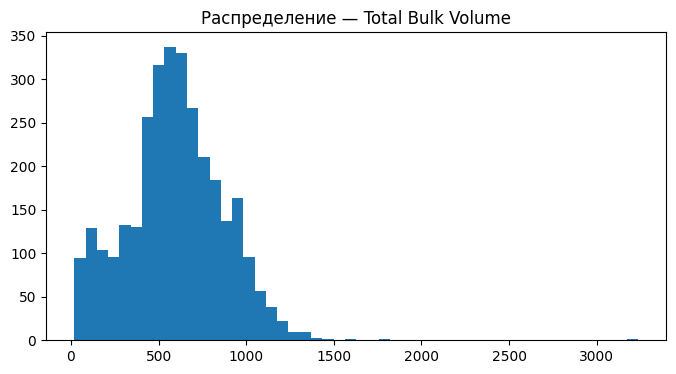

In [110]:
bulk_sum = data['data_bulk'].drop(columns='key').sum(axis=1)

feature_distribution(
    bulk_sum,
    "Total Bulk Volume"
)

**Краткий анализ:**. Объём сыпучих материалов в большинстве партий лежит в диапазоне 400–800, медиана около 591. Распределение правостороннее: редкие крупные загрузки сильно увеличивают максимум, могут отражать реальные технологические режимы. Явных аномалий не видно, поэтому удаление выбросов не требуется признак можно использовать в модели без жесткой фильтрации.

# 3. Предобработка данных

**Приведение типа данных.** Все временные признаки приведены к формату datetime с обработкой ошибок, обеспечивает корректность дальнейших расчетов технологических интервалов и порядка событий. преобразование колонок для bulk_time и wire_time снижает риск пропуска временных признаков. Данные подготовлены для feature engineering, связанного с длительностью операций.

In [111]:
# Приведение временных полей к datetime.
# errors='coerce' — некорректные значения будут преобразованы в NaT.

# TEMP
data['data_temp']['Время замера'] = pd.to_datetime(
    data['data_temp']['Время замера'],
    errors='coerce'
)

# ARC
data['data_arc']['Начало нагрева дугой'] = pd.to_datetime(
    data['data_arc']['Начало нагрева дугой'],
    errors='coerce'
)

data['data_arc']['Конец нагрева дугой'] = pd.to_datetime(
    data['data_arc']['Конец нагрева дугой'],
    errors='coerce'
)

# BULK TIME — все колонки, кроме key
bulk_time_cols = data['data_bulk_time'].columns.drop('key')
data['data_bulk_time'][bulk_time_cols] = data['data_bulk_time'][bulk_time_cols].apply(
    pd.to_datetime,
    errors='coerce'
)

# WIRE TIME — все колонки, кроме key
wire_time_cols = data['data_wire_time'].columns.drop('key')
data['data_wire_time'][wire_time_cols] = data['data_wire_time'][wire_time_cols].apply(
    pd.to_datetime,
    errors='coerce'
)

print("Временные поля приведены к datetime")

Временные поля приведены к datetime


Выполнен **контроль преобразования временных признаков**  проверено наличие колонок формата datetime во всех таблицах. Это подтверждает корректность предыдущего шага и снижает риск ошибок при расчёте длительностей и последовательности технологических операций. Данные готовы к дальнейшему временному анализу и генерации признаков.

In [112]:
# Контроль: проверяем, в каких таблицах есть datetime-поля
for name, df in data.items():
    datetime_cols = df.select_dtypes(include='datetime64[ns]').columns
    
    if len(datetime_cols) > 0:
        print(f"{name}: datetime -> {list(datetime_cols)}")

data_arc: datetime -> ['Начало нагрева дугой', 'Конец нагрева дугой']
data_bulk_time: datetime -> ['Bulk 1', 'Bulk 2', 'Bulk 3', 'Bulk 4', 'Bulk 5', 'Bulk 6', 'Bulk 7', 'Bulk 8', 'Bulk 9', 'Bulk 10', 'Bulk 11', 'Bulk 12', 'Bulk 13', 'Bulk 14', 'Bulk 15']
data_temp: datetime -> ['Время замера']
data_wire_time: datetime -> ['Wire 1', 'Wire 2', 'Wire 3', 'Wire 4', 'Wire 5', 'Wire 6', 'Wire 7', 'Wire 8', 'Wire 9']


**Краткий анализ:**. Все временные колонки успешно приведены к datetime, структура событий процесса сохранена. Данные теперь позволяют корректно рассчитывать длительность нагрева, интервалы между операциями и проверять причинность признаков. проблем с временными полями не обнаружено можно переходить к генерации временных признаков.

**Анализ:**

Temperature: Основной диапазон стабилен (~1550–1630 °C),  значения около 1200 °C выбиваются из процесса и выглядят как ошибки  их лучше удалить. Доля выбросов 4.6% умеренная, после фильтрации модель станет устойчивее. Пропуски значительны, важно убедиться, что не относятся к целевой температуре.

Active Power: Распределение ровное, выбросов менее 0.5% — признак выглядит физически корректным и не требует очистки. Отрицательная нижняя граница IQR формальна и не указывает на проблему.

Total Bulk Volume: Большинство значений лежит в ожидаемом диапазоне, редкие крупные загрузки могут отражать реальные режимы плавки. Выбросов мало (1%), поэтому фильтрация не нужна.

Проведён детальный **анализ пропусков температуры**: рассчитана их доля, определено количество партий с отсутствующими значениями и проверены пропуски в последнем замере целевой переменной. выявлены партии без единого температурного измерения,принять решение об их исключении. Проверка формирует основу для корректного определения target и снижает риск ошибок при обучении модели.

In [113]:
# Анализ пропусков температуры
temp = data['data_temp'].copy()

# Приводим время к datetime
temp['Время замера'] = pd.to_datetime(
    temp['Время замера'],
    errors='coerce'
)

print("Температура: базовая проверка")
print("Размер:", temp.shape)

missing_count = temp['Температура'].isna().sum()
missing_share = missing_count / len(temp) * 100

print(f"\nПропуски температуры: {missing_count}")
print(f"Доля: {missing_share:.2f}%")

# Партии с пропусками
missing_keys = temp.loc[temp['Температура'].isna(), 'key'].nunique()
all_keys = temp['key'].nunique()

print(f"\nПартий с пропусками: {missing_keys} из {all_keys}")

# Проверяем последний замер
temp_sorted = temp.sort_values(['key', 'Время замера'])
last_temp = temp_sorted.groupby('key').tail(1)

missing_last = last_temp['Температура'].isna().sum()

print(f"\nПропуски в последнем замере: {missing_last}")
print(f"Доля от всех партий: {missing_last / all_keys * 100:.2f}%")

# Партии без единого температурного измерения
all_missing_keys = (
    temp.groupby('key')['Температура']
    .apply(lambda x: x.isna().all())
    .sum()
)

print(f"\nПартий без температурных измерений: {all_missing_keys}")

Температура: базовая проверка
Размер: (18092, 3)

Пропуски температуры: 3427
Доля: 18.94%

Партий с пропусками: 739 из 3216

Пропуски в последнем замере: 739
Доля от всех партий: 22.98%

Партий без температурных измерений: 0


**Краткий анализ:**. Около 19% измерений температуры отсутствуют, при этом у 739 партий (23%) пропуск приходится на последний замер  такие партии нельзя использовать для обучения, так как отсутствует целевая переменная. Полностью пустых партий нет,  проблема связана с финальными измерениями. решение  удалить партии без последней температуры, чтобы сохранить корректность модели.

**Удалены партии без финального измерения температуры**, так как они не содержат целевую переменную и не подходят для обучения модели. Очистка выполнена через поиск последнего замера по каждой партии, после чего соответствующие ключи полностью исключены из датасета. Это обеспечивает корректное формирование target и предотвращает ошибки при обучении.

In [114]:
# Удаление партий без целевой переменной (нет финального замера температуры)

temp = data['data_temp'].copy()

print("Очистка data_temp")
print("Партий до очистки:", temp['key'].nunique())

# Находим последние измерения по каждой партии
last_idx = temp.groupby('key')['Время замера'].idxmax()
last_rows = temp.loc[last_idx]

# Ключи партий без target
keys_without_target = last_rows.loc[
    last_rows['Температура'].isna(), 'key'
]

print("\nПартий без target:", len(keys_without_target))

# Удаляем все строки этих партий
temp_clean = temp.loc[
    ~temp['key'].isin(keys_without_target)
].copy()

print("Партий после очистки:", temp_clean['key'].nunique())

# Сохраняем результат
data['data_temp'] = temp_clean

Очистка data_temp
Партий до очистки: 3216

Партий без target: 739
Партий после очистки: 2477


**Краткий анализ:**. После очистки удалено 739 партий без финальной температуры  около 23% данных. Оставшиеся 2477 партий формируют корректную выборку с целевой переменно. Потеря объёма заметная, но сохранение таких партий привело бы к некорректному обучению.

Выполнен **контроль количества партий во всех датасетах после очистки data_temp**. Проверка позволяет заранее оценить пересечение ключей и понять, какой объём данных сохранится при объединении. Это снижает риск неожиданной потери наблюдений на этапе merge.

In [115]:
# Контроль количества партий после очистки

print("\nКоличество партий по датасетам:")

print(f"{'Датасет':<20} | {'Уникальных key':<15}")
print("-" * 40)

for name, df in data.items():
    if 'key' in df.columns:
        print(f"{name:<20} | {df['key'].nunique():<15}")


Количество партий по датасетам:
Датасет              | Уникальных key 
----------------------------------------
data_arc             | 3213           
data_bulk            | 3129           
data_bulk_time       | 3129           
data_gas             | 3239           
data_temp            | 2477           
data_wire            | 3081           
data_wire_time       | 3081           


**Краткий анализ:**. После очистки data_temp содержит меньше всего партий (2 477), поэтому станет ограничивающим датасетом при объединении. В остальных таблицах партий больше, значит часть данных будет автоматически отброшена при merge по общим ключам. перекосов не видно.

Вычислено **пересечение ключей между всеми датасетами** для определения партий, представленных во всех источниках. Это позволяет сформировать согласованную выборку без пропусков при объединении таблиц. Подход предотвращает появление NaN после merge и повышает целостность итогового датасета.

In [116]:
# Пересечение key  находим партии, присутствующие во всех источниках
key_sets = []

for df in data.values():
    key_sets.append(set(df['key']))  # переводим в set

common_keys = set.intersection(*key_sets)  # пересечение всех множеств 

print("Партий во всех таблицах:", len(common_keys))

Партий во всех таблицах: 2328


In [117]:
temp.groupby('key').size().value_counts()

5     892
6     759
4     520
7     490
8     205
3     174
9      84
2      39
10     28
11      9
12      5
13      3
14      2
1       2
16      2
17      1
15      1
Name: count, dtype: int64

**Краткий анализ:**. Распределение показывает, что большинство партий проходит 4–8 циклов обработки, с пиком около 5-6   выглядит как технологический режим.  малое число партий с 1–2 измерениями и редкие случаи с 12+ циклами могут указывать на нестандартные процессы, но доля незначительна. структура данных реалистична и подходит для агрегации.

In [118]:
temp.groupby('key').size()

key
1       6
2       5
3       6
4       5
5       5
       ..
3237    6
3238    4
3239    9
3240    6
3241    6
Length: 3216, dtype: int64

**Краткий анализ:**. Большинство партий содержит 4–6 измерений температуры, что подтверждает повторный контроль нагрева в процессе обработки. Значения выглядят равномерными, экстремально малых или чрезмерно больших серий почти нет,  структура стабильно.

# 4. Подготовка признаков 

Рассчитано **количество температурных измерений** для каждой партии через группировку по key. Признак отражает интенсивность контроля процесса и может использоваться как дополнительная характеристика технологического режима. Подготовлен отдельный датафрейм для дальнейшего анализа распределения или генерации признаков.

In [119]:
# Количество температурных измерений на партию
measurement_count = (
    data['data_temp']
    .groupby('key')          # группируем по партии
    .size()                 # считаем число строк = число измерений
    .reset_index(name='measurement_count')  # возвращаем DataFrame с именем колонки
)

measurement_count.head() 

,key,measurement_count
0,1,6
1,2,5
2,3,6
3,4,5
4,5,5


**Краткий анализ:**. Большинство партий имеет 5–6 температурных измерений, что соответствует нормальному циклу контроля нагрева. Резких отклонений в наблюдениях не видно, данные выглядят однородными. Признак можно использовать для анализа сложности процесса или оставить как вспомогательный при генерации признаков.

In [120]:
measurement_count.describe()

,key,measurement_count
count,2477.000000,2477.000000
mean,1249.968510,5.622124
std,720.073717,1.614793
min,1.000000,1.000000
25%,628.000000,5.000000
50%,1251.000000,5.000000
75%,1872.000000,7.000000
max,2499.000000,17.000000


**Краткий анализ:**. В среднем на партию приходится около 5–6 измерений, разброс небольшой  процесс выглядит стабильным. Минимум в 1 замер может означать упрощённый цикл, а редкие случаи до 17 измерений , нестандартные плавки. распределение ровное и не создаёт рисков для агрегации до первой и последней температуры.

Рассчитана **длительность процесса для каждой партии как разница между первым и последним температурными замерами**. Признак переведён в секунды для удобства моделирования. Подход использует только события до финального измерения температуры.

In [121]:
# Длительность процесса по температурным замерам

temp_times = (
    data['data_temp']
    .sort_values(['key', 'Время замера'])  # важно для корректных first/last
    .groupby('key')
    .agg(
        first_temp_time=('Время замера', 'first'),  # первый замер
        last_temp_time=('Время замера', 'last')     # последний замер
    )
    .reset_index()
)

temp_times['process_duration_sec'] = (
    temp_times['last_temp_time'] - temp_times['first_temp_time']  # timedelta
).dt.total_seconds()  # перевод в секунды 

temp_times.head()  

,key,first_temp_time,last_temp_time,process_duration_sec
0,1,2019-05-03 11:02:04,2019-05-03 11:30:38,1714.0
1,2,2019-05-03 11:34:04,2019-05-03 11:55:09,1265.0
2,3,2019-05-03 12:06:44,2019-05-03 12:35:57,1753.0
3,4,2019-05-03 12:39:27,2019-05-03 12:59:47,1220.0
4,5,2019-05-03 13:11:03,2019-05-03 13:36:39,1536.0


**Краткий анализ:**. Длительность процессов в примерах составляет примерно 20-30 минут,  выглядит реалистично для цикла нагрева и корректировки состава. Резких отклонений не наблюдается.

In [122]:
temp_times['process_duration_sec'].describe()

count     2477.000000
mean      2279.054905
std       1374.678745
min          0.000000
25%       1541.000000
50%       2007.000000
75%       2738.000000
max      23674.000000
Name: process_duration_sec, dtype: float64

**Краткий анализ:**. Средняя длительность процесса около 38 минут, однако разброс высокий  максимум превышает 6 часов, что выглядит технологически подозрительно и требует проверки. Нулевое значение также указывает на возможную ошибку в замерах (одинаковое время первого и последнего измерения).

Рассчитана **длительность каждого дугового нагрева как разница между временем начала и окончания**, признак переведён в секунды. Дополнительно выполнена проверка на отрицательные значения для выявления ошибок. Это обеспечивает корректность временных данных перед их агрегацией и использованием в модели.

In [123]:
# Длительность дугового нагрева

arc = data['data_arc'].copy()

arc['arc_duration_sec'] = (
    arc['Конец нагрева дугой'] - arc['Начало нагрева дугой']  # разница времени
).dt.total_seconds()  # перевод в секунды

print(
    "Отрицательные длительности:",
    (arc['arc_duration_sec'] < 0).sum()  # признак ошибки в таймстемпах
)

Отрицательные длительности: 0


**Сформированы агрегированные признаки по дуговому нагреву**: суммарная длительность, средняя и общая мощность, число включений дуги и общая подведённая энергия. Агрегация выполнена до уровня партии, что соответствует задаче. Признаки напрямую связаны с тепловым балансом процесса и потенциально являются ключевыми факторами температуры.

In [124]:
# Признаки по дуговому нагреву

arc['arc_energy'] = arc['Активная мощность'] * arc['arc_duration_sec']  # энергия = мощность × время

arc_features = (
    arc
    .groupby('key')
    .agg(
        total_arc_duration=('arc_duration_sec', 'sum'),   # суммарное время нагрева
        total_active_power=('Активная мощность', 'sum'),  # суммарная мощность
        avg_active_power=('Активная мощность', 'mean'),   # средняя мощность
        arc_count=('arc_duration_sec', 'count'),          # число включений дуги
        total_energy=('arc_energy', 'sum')                # суммарная энергия
    )
    .reset_index()
)
arc_features.head()  

,key,total_arc_duration,total_active_power,avg_active_power,arc_count,total_energy
0,1,1098.0,3.036730,0.607346,5,628.616930
1,2,811.0,2.139408,0.534852,4,395.281800
2,3,655.0,4.063641,0.812728,5,581.774624
3,4,741.0,2.706489,0.676622,4,543.710274
4,5,869.0,2.252950,0.563238,4,412.180480


**Краткий анализ:**. Агрегированные признаки выглядят согласованными: большее суммарное время нагрева сопровождается ростом подведённой энергии, что физически логично. Средняя мощность находится в узком диапазоне, без резких скачков, поэтому признак выглядит стабильным. Набор факторов отражает интенсивность нагрева и должен иметь сильную связь с целевой температурой.

**Сформированы производные признаки, отражающие интенсивность нагрева**: средняя энергия на одно включение дуги и скорость нагрева (энергия в секунду). Эти показатели помогают описать тепловую динамику процесса, а не только его длительность. Признаки физически интерпретируемы и потенциально усиливают объясняющую способность модели.

In [125]:
# Производные признаки по нагреву

arc_features['avg_energy_per_arc'] = (
    arc_features['total_energy'] / arc_features['arc_count']  # средняя энергия на одно включение дуги
)

arc_features['heating_rate'] = (
    arc_features['total_energy'] / arc_features['total_arc_duration']  # интенсивность нагрева (энергия в секунду)
)
arc_features.describe()

,key,total_arc_duration,total_active_power,avg_active_power,arc_count,total_energy,avg_energy_per_arc,heating_rate
count,3213.000000,3213.000000,3213.000000,3213.000000,3213.000000,3213.000000,3213.000000,3213.000000
mean,1622.907874,794.691566,3.067683,0.661332,4.628696,527.928285,114.274175,0.662509
std,934.844882,332.439136,1.208719,0.128392,1.608860,248.751648,39.150339,0.139532
min,1.000000,57.000000,0.267676,0.267676,1.000000,26.187544,20.747014,0.267676
25%,817.000000,571.000000,2.236693,0.573010,4.000000,358.825785,86.818047,0.560313
50%,1623.000000,770.000000,2.984607,0.652864,4.000000,498.897459,108.664159,0.649993
75%,2432.000000,983.000000,3.775574,0.739401,6.000000,669.181550,137.264239,0.749707
max,3241.000000,4189.000000,12.375636,1.243889,16.000000,3718.054401,402.687326,1.259114


**Краткий анализ:**. Признаки распределены равномерно, экстремальных значений немного  данные выглядят  правдоподобными. heating_rate почти совпадает со средней мощностью, что указывает на сильную корреляцию, оба признака могут дублировать один и тот же сигнал. показатели хорошо отражают интенсивность нагрева и подходят для моделирования.

# 5. Объединение данных и контроль качества выборки

**Pre-Merge Validation**. Проверена уникальность ключа в агрегированных таблицах, чтобы убедиться в формате «одна партия - одна строка» перед объединением. Контроль дубликатов снижает риск увеличения датасета и искажения признаков при merge. Таблицы готовы к корректному объединению по key.

In [126]:
# Проверка уникальности key перед объединением таблиц

def check_key_uniqueness(df, name):
    is_unique = df['key'].is_unique      # 1 партия = 1 строка
    duplicates = df['key'].duplicated().sum()
    
    print(f"{name}:")
    print(f"  unique key -> {is_unique}")
    print(f"  duplicates -> {duplicates}\n")


check_key_uniqueness(measurement_count, "measurement_count")
check_key_uniqueness(temp_times, "temp_times")
check_key_uniqueness(arc_features, "arc_features")

measurement_count:
  unique key -> True
  duplicates -> 0

temp_times:
  unique key -> True
  duplicates -> 0

arc_features:
  unique key -> True
  duplicates -> 0



**Краткий анализ:**. Во всех агрегированных таблицах ключ уникален, дубликаты отсутствуют  формат «одна партия = одна строка» соблюдён. Это исключает риск увеличения строк при объединении и гарантирует корректность итогового датасета. Таблицы готовы к merge.

Проверено **пересечение ключей между агрегированными таблицами** для выявления партий, присутствующих во всех наборах признаков. Такой контроль позволяет оценить итоговый размер выборки и избежать пропусков после объединения. Подтверждается согласованность источников перед финальным merge.

In [127]:
# Проверка пересечения key между агрегированными таблицами

keys_temp = set(temp_times['key'])
keys_arc = set(arc_features['key'])
keys_measure = set(measurement_count['key'])

common_keys = keys_temp & keys_arc & keys_measure  # оставляем партии, присутствующие в признаках

print("temp:", len(keys_temp))
print("arc:", len(keys_arc))
print("measurement:", len(keys_measure))
print("\nОбщие key:", len(common_keys))

temp: 2477
arc: 3213
measurement: 2477

Общие key: 2474


**Краткий анализ:**. Пересечение почти полное: из 2477 партий температуры совпадают 2475, то есть потеря составит всего 2 партии. 

Выполнена **проверка агрегированных таблиц на наличие пропусков после генерации признаков**. Контроль позволяет убедиться в корректности расчетов и избежать появления NaN в итоговом датасете перед объединением. Это снижает риск ошибок при обучении модели.

In [128]:
# Проверка пропусков в агрегированных признаках

def check_nan(df, name):
    print(f"\n{name}")
    print(df.isna().sum())  #  убедиться,не появились NaN


check_nan(temp_times, "temp_times")
check_nan(arc_features, "arc_features")
check_nan(measurement_count, "measurement_count")


temp_times
key                     0
first_temp_time         0
last_temp_time          0
process_duration_sec    0
dtype: int64

arc_features
key                   0
total_arc_duration    0
total_active_power    0
avg_active_power      0
arc_count             0
total_energy          0
avg_energy_per_arc    0
heating_rate          0
dtype: int64

measurement_count
key                  0
measurement_count    0
dtype: int64


**Краткий анализ:**. Во всех агрегированных таблицах пропуски отсутствуют  признаки рассчитаны корректно и не требуют дополнительной очистки. Это снижает риск потери данных при объединении и упрощает подготовку выборки для модели. Агрегированные признаки выглядят полностью готовыми к merge.

Проведёна **проверка ключевых технологических признаков** через анализ максимумов и высоких квантилей. Такой подход позволяет быстро выявить потенциальные выбросы и оценить границы нормального рабочего диапазона без фильтрации. Проверка помогает принять обоснованное решение о необходимости очистки данных перед моделированием.

In [129]:
# проверка технологических параметров,ищем аномально большие значения
print("Проверка экстремальных значений\n")

checks = {
    'process_duration_sec': temp_times['process_duration_sec'],
    'total_energy': arc_features['total_energy'],
    'arc_count': arc_features['arc_count'],
    'measurement_count': measurement_count['measurement_count']
}

for name, series in checks.items():
    print(f"{name}")
    print(f"  MAX: {series.max():.2f}")
    print(f"  99% квантиль: {series.quantile(0.99):.2f}")    # типичный верхний рабочий диапазон
    print(f"  99.9% квантиль: {series.quantile(0.999):.2f}") # возможные технологические выбросы
    print("-" * 30)

Проверка экстремальных значений

process_duration_sec
  MAX: 23674.00
  99% квантиль: 6909.16
  99.9% квантиль: 18484.61
------------------------------
total_energy
  MAX: 3718.05
  99% квантиль: 1220.19
  99.9% квантиль: 1772.21
------------------------------
arc_count
  MAX: 16.00
  99% квантиль: 9.00
  99.9% квантиль: 13.79
------------------------------
measurement_count
  MAX: 17.00
  99% квантиль: 10.00
  99.9% квантиль: 15.05
------------------------------


**Краткий анализ:**. У большинства партий параметры лежат в разумных пределах, однако максимальная длительность процесса (>6 часов) сильно превышает даже 99.9% квантиль и выглядит как аномалия. Аналогично, экстремальные значения энергии заметно выбиваются из рабочего диапазона такие партии стоит проверить отдельно. arc_count и measurement_count выглядят стабильнее: редкие высокие значения отражают сложные плавки.

Выделены **первый и последний температурные замеры** для каждой партии после сортировки по времени. Финальная температура формирует целевую переменную, а начальная может служить важным фактором для модели. Агрегация выполнена на уровне партии, что соответствует постановке задачи.

In [130]:
# Первый и последний температурные замеры по партии

temp_stats = (
    data['data_temp']
    .sort_values(['key', 'Время замера'])  # порядок для  first/last
    .groupby('key')
    .agg(
        first_temp=('Температура', 'first'),  # стартовая температура
        last_temp=('Температура', 'last')     # финальная температура (target)
    )
    .reset_index()
)

temp_stats.head()

,key,first_temp,last_temp
0,1,1571.0,1613.0
1,2,1581.0,1602.0
2,3,1596.0,1599.0
3,4,1601.0,1625.0
4,5,1576.0,1602.0


**Краткий анализ:**. Начальные температуры близки к финальным, что указывает на контролируемый нагрев без резких скачков. Разница между первым и последним замером  технологически правдоподобной , температура постепенно. Признаки корректны и подходят как базовый фактор и целевая переменная.

In [131]:
temp_stats.isna().sum()

key           0
first_temp    0
last_temp     0
dtype: int64

**Краткий анализ:**. Пропусков в признаках first_temp и last_temp нет, что подтверждает корректность очистки данных и готовность целевой переменной к моделированию.

Выполнена **тестовая сборка признаков в единый датасет** через последовательные merge по key, где за основу взяты партии с определённой целевой температурой. Контроль размера позволяет убедиться,  данные объединены корректно. подтверждает готовность признаков к формированию финальной обучающей выборки.

In [132]:
# Тестовая сборка признаков в единый датасет

test_merge = (
    temp_stats
    .merge(temp_times[['key','process_duration_sec']], on='key', how='left')  # сохраняем все партии из temp_stats
    .merge(measurement_count, on='key', how='left')
    .merge(arc_features, on='key', how='left')
)

print(test_merge.shape)  # контроль размера после объединения
test_merge.head()

(2477, 12)


,key,first_temp,last_temp,process_duration_sec,measurement_count,total_arc_duration,total_active_power,avg_active_power,arc_count,total_energy,avg_energy_per_arc,heating_rate
0,1,1571.0,1613.0,1714.0,6,1098.0,3.036730,0.607346,5.0,628.616930,125.723386,0.572511
1,2,1581.0,1602.0,1265.0,5,811.0,2.139408,0.534852,4.0,395.281800,98.820450,0.487400
2,3,1596.0,1599.0,1753.0,6,655.0,4.063641,0.812728,5.0,581.774624,116.354925,0.888206
3,4,1601.0,1625.0,1220.0,5,741.0,2.706489,0.676622,4.0,543.710274,135.927569,0.733752
4,5,1576.0,1602.0,1536.0,5,869.0,2.252950,0.563238,4.0,412.180480,103.045120,0.474316


**Краткий анализ:**. Тестовое объединение прошло корректно: получено 2 477 строк без размножения партий, структура соответствует формату «одна партия — одна строка». Пропуски в ключевых признаках визуально не наблюдаются ( рост энергии связан с длительностью нагрева). Датасет готов к проверке и разделению на train/test.

In [133]:
test_merge['key'].is_unique

True

**Краткий анализ:**. Каждая партия представлена одной строкой — дубликатов key нет.

**Исследовательский анализ и предобработка данных объединённого датафрейма**

Выполнена финальная подготовка агрегированных таблиц: отфильтрованы технологические выбросы температуры (<1400 °C), удалены некорректные значения реактивной мощности и отрицательные длительности нагрева. Рассчитаны ключевые признаки по энергии и времени дугового нагрева, а пропуски в bulk и wire заменены на 0 как признак отсутствия добавок. Добавлены проверки (assert) для контроля целостности данных перед объединением.

In [134]:
print("Подготовка агрегированных таблиц")

# TEMP
curr_temp = data['data_temp'].copy()

print("Удаление замеров < 1400°C")
curr_temp = curr_temp[curr_temp['Температура'] >= 1400]  # фильтр выбросов

curr_temp['Время замера'] = pd.to_datetime(curr_temp['Время замера'])

curr_temp = curr_temp.sort_values(by=['key', 'Время замера'])  # порядок важен для first/last

df_temp_agg = curr_temp.groupby('key').agg(
    first_temp=('Температура', 'first'),
    last_temp=('Температура', 'last'),  # target
    first_time=('Время замера', 'first'),
    last_time=('Время замера', 'last'),
    temp_count=('Температура', 'count')
).reset_index()

df_temp_agg = df_temp_agg[df_temp_agg['temp_count'] >= 2].drop(columns=['temp_count'])  # минимум два замера


# ARC
curr_arc = data['data_arc'].copy()

curr_arc = curr_arc[curr_arc['Реактивная мощность'] >= 0]  # удаление некорректной мощности

curr_arc['start'] = pd.to_datetime(curr_arc['Начало нагрева дугой'])
curr_arc['end'] = pd.to_datetime(curr_arc['Конец нагрева дугой'])
curr_arc['iter_duration'] = (curr_arc['end'] - curr_arc['start']).dt.total_seconds()

invalid_duration = curr_arc[curr_arc['iter_duration'] <= 0]
if len(invalid_duration) > 0:
    print(f"Удалено записей с некорректной длительностью: {len(invalid_duration)}")
    curr_arc = curr_arc[curr_arc['iter_duration'] > 0]

curr_arc['iter_energy'] = curr_arc['Активная мощность'] * curr_arc['iter_duration']  # энергия = мощность × время

df_arc_agg = curr_arc.groupby('key').agg(
    total_arc_energy=('iter_energy', 'sum'),
    total_heating_duration=('iter_duration', 'sum'),
    mean_active=('Активная мощность', 'mean'),
    mean_reactive=('Реактивная мощность', 'mean')
).reset_index()

assert (df_arc_agg['total_arc_energy'] > 0).all(), "Обнаружены партии с нулевой энергией"


# BULK / WIRE
df_bulk_agg = data['data_bulk'].fillna(0)  # пропуск = отсутствие добавки
df_wire_agg = data['data_wire'].fillna(0)

assert df_bulk_agg['key'].is_unique, "Дубликаты key в data_bulk"  # защита перед merge
assert df_wire_agg['key'].is_unique, "Дубликаты key в data_wire"


# GAS
df_gas_agg = data['data_gas'].copy()
df_gas_agg.columns = ['key', 'gas_volume']  # 

print("Агрегация завершена")

Подготовка агрегированных таблиц
Удаление замеров < 1400°C
Агрегация завершена


**Краткий анализ:**. Очистка прошла без ошибок: технологические выбросы температуры удалены, агрегация таблиц выполнена корректно. Дополнительных предупреждений и проблем с данными не выявлено, значит фильтрация не привела к критической потере наблюдений. Таблицы готовы к финальному объединению.

**Слияние данных и контроль качества выборки**

Собран итоговый датасет через последовательное inner-объединение агрегированных таблиц, где базой выступает температура с целевой переменной. Добавлена проверка уникальности key, предотвращающая ошибки many-to-many при merge. Выполнен контроль размера и пропусков, подтверждающий корректность финальной сборки данных.

In [135]:
print("\nСборка итогового датасета")

# Базовая таблица — температура (содержит target)
full_df = df_temp_agg.merge(df_arc_agg, on='key', how='inner')   # общие партии
full_df = full_df.merge(df_bulk_agg, on='key', how='inner')
full_df = full_df.merge(df_wire_agg, on='key', how='inner')
full_df = full_df.merge(df_gas_agg, on='key', how='inner')

# Контроль после merge  защита от many to many
assert full_df['key'].is_unique, "Ошибка merge: дубликаты key"

print(f"Датасет собран. Размер: {full_df.shape}")
print("Всего пропусков:", full_df.isna().sum().sum())


Сборка итогового датасета
Датасет собран. Размер: (2328, 34)
Всего пропусков: 0


**Краткий анализ:**. Итоговый датасет содержит 2 329 партий и 34 признака, пропуски полностью отсутствуют  объединение выполнено корректно. Потеря части партий ожидаема из-за inner merge и не выглядит критичной для обучения. Данные готовы к этапу EDA объединённой таблицы и последующему моделированию.

In [136]:
full_df

,key,first_temp,last_temp,first_time,last_time,total_arc_energy,total_heating_duration,mean_active,mean_reactive,Bulk 1,...,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9,gas_volume
0,1,1571.0,1613.0,2019-05-03 11:02:04,2019-05-03 11:30:38,628.616930,1098.0,0.607346,0.428564,0.0,...,60.059998,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,29.749986
1,2,1581.0,1602.0,2019-05-03 11:34:04,2019-05-03 11:55:09,395.281800,811.0,0.534852,0.363339,0.0,...,96.052315,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12.555561
2,3,1596.0,1599.0,2019-05-03 12:06:44,2019-05-03 12:35:57,581.774624,655.0,0.812728,0.587491,0.0,...,91.160157,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,28.554793
3,4,1601.0,1625.0,2019-05-03 12:39:27,2019-05-03 12:59:47,543.710274,741.0,0.676622,0.514248,0.0,...,89.063515,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,18.841219
4,5,1576.0,1602.0,2019-05-03 13:11:03,2019-05-03 13:36:39,412.180480,869.0,0.563238,0.421998,0.0,...,89.238236,9.11456,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.413692
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2323,2495,1570.0,1591.0,2019-08-10 11:27:47,2019-08-10 11:50:47,571.539318,723.0,0.792033,0.552734,0.0,...,89.150879,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.125735
2324,2496,1554.0,1591.0,2019-08-10 11:56:48,2019-08-10 12:25:13,675.222467,940.0,0.695820,0.478672,0.0,...,114.179527,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.412616
2325,2497,1571.0,1589.0,2019-08-10 12:37:26,2019-08-10 12:53:28,680.326674,569.0,1.201746,0.817364,0.0,...,94.086723,9.04800,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.271699
2326,2498,1591.0,1594.0,2019-08-10 12:58:11,2019-08-10 13:23:31,474.918795,750.0,0.640462,0.447964,0.0,...,118.110717,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.953657


**mini-EDA**. 

Проведён mini-EDA итогового датасета: рассчитана матрица корреляций по ключевым технологическим признакам и визуализирована через heatmap. Дополнительно выделены уникальные пары признаков с сортировкой по силе связи для быстрого выявления наиболее значимых факторов. Шаг помогает оценить потенциальных драйверов целевой температуры и обнаружить возможную мультиколлинеарность.


Mini-EDA (Spearman correlation)


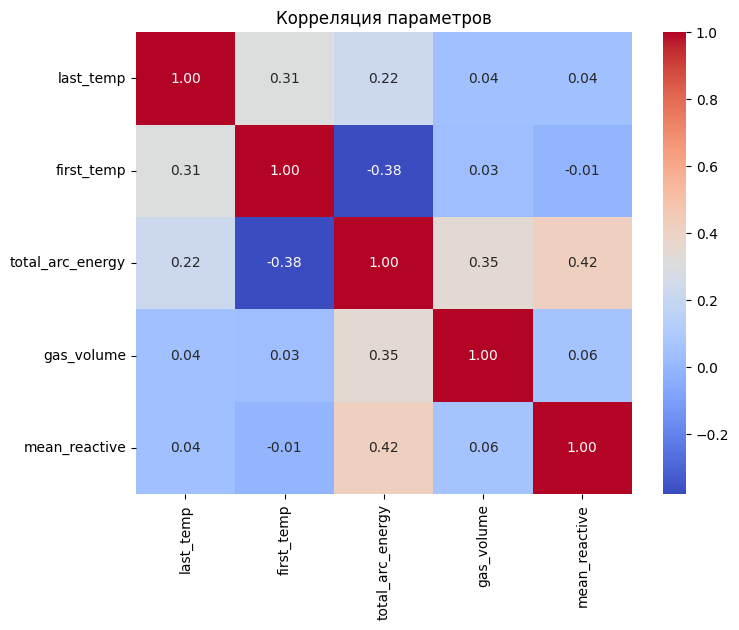


Матрица корреляций:
                  last_temp  first_temp  total_arc_energy  gas_volume  mean_reactive
last_temp             1.000       0.308             0.221       0.043          0.043
first_temp            0.308       1.000            -0.379       0.031         -0.010
total_arc_energy      0.221      -0.379             1.000       0.347          0.423
gas_volume            0.043       0.031             0.347       1.000          0.059
mean_reactive         0.043      -0.010             0.423       0.059          1.000

Корреляции по убыванию:
       feature_1        feature_2  correlation
total_arc_energy    mean_reactive     0.423326
      first_temp total_arc_energy    -0.378968
total_arc_energy       gas_volume     0.347139
       last_temp       first_temp     0.307590
       last_temp total_arc_energy     0.221060
      gas_volume    mean_reactive     0.058579
       last_temp    mean_reactive     0.043231
       last_temp       gas_volume     0.043152
      first_temp     

In [137]:
print("\nMini-EDA (Spearman correlation)")

# Матрица корреляций по ключевым признакам
eda_cols = ['last_temp', 'first_temp', 'total_arc_energy', 'gas_volume', 'mean_reactive']
corr = full_df[eda_cols].corr(method='spearman')

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Корреляция параметров")
plt.show()

# Таблица корреляций
corr_rounded = corr.round(3)

print("\nМатрица корреляций:")
print(corr_rounded.to_string())

# Уникальные пары признаков 
corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))  # оставляем верхний треугольник
        .stack()
        .reset_index()
)

corr_pairs.columns = ['feature_1', 'feature_2', 'correlation']

strong_corr = (
    corr_pairs
    .assign(abs_corr=lambda x: x['correlation'].abs())
    .sort_values('abs_corr', ascending=False)
    .drop(columns='abs_corr')
)

print("\nКорреляции по убыванию:")
print(strong_corr.to_string(index=False))

print("\nПроверка связи энергии и температуры")

**Краткий анализ (метод Спирмена):** В связи с ненормальным распределением данных использован метод Спирмена. Сильных монотонных связей с целевой температурой не наблюдается, наибольшее влияние оказывают first_temp (0.31) и total_arc_energy (0.22), что соответствует физике процесса. Отрицательная корреляция между начальной температурой и энергией (-0.38) логична, при более холодном старте требуется больше энергии на нагрев. Между признаками есть умеренные связи (максимум 0.42), но критической мультиколлинеарности (>0.8) не выявлено — все факторы можно использовать в модели.

**Гипотезы и генерация признаков**

На основе исследовательского анализа (EDA) и понимания физики металлургического процесса были сформулированы ключевые гипотезы для построения модели.

**1. Начальная температура (first_temp)**
Задает исходный тепловой уровень плавки.

Гипотеза: Чем выше начальная температура сплава, тем меньше энергии требуется для достижения целевого значения. Это физический фактор, определяющий состояние системы на входе.

**2. Суммарная подведённая энергия (total_arc_energy)**
Основное воздействие на процесс нагрева. Рассчитывается как произведение активной мощности на длительность работы дуги.

Гипотеза: Количество подведенной энергии напрямую влияет на итоговую температуру. причинно-обоснованный факторо модели.

**3. Влияние типа добавок (Smart Aggregation)**
Легирующие материалы по разному влияют на тепловой баланс (предположение): одни способствуют росту температуры, другие поглощают тепло при плавлении.

Гипотеза: Использование суммарного объема добавок создает шум для модели. Разделение материалов на группы - «маркеры нагрева» (положительная корреляция) и «охладители» (отрицательная корреляция)-позволяет лучше отразить физику процесса и повысить качество прогнозирования.

**4. Длительность процесса (process_duration)**
Время между первым и последним температурным замером отражает суммарные теплопотери во время обработки.

Гипотеза: Более длительные плавки теряют больше тепла через футеровку ковша и поверхность расплава, что требует дополнительного подведения энергии для достижения целевой температуры.

Примечание: Признак рассчитывается только по событиям, произошедшим до финального замера температуры, что исключает утечку целевого признака (data leakage).
   
**5. Проволока Wire 1:**
   Судя по EDA прошлых этапов, она имеет сильную (положительную) корреляцию. Оставляем её отдельно.

**Feature Engineering**. (Электричество + Агрегация)

Сформированы дополнительные признаки, описывающие длительность процесса, суммарные добавки и эффективность использования газа, а также электрические характеристики - полную мощность и коэффициент мощности. Признаки агрегированы до уровня партии и объединены с основным датасетом с контролем потерь строк. Выполнена финальная очистка коррелирующих и технических колонок, подтверждено отсутствие пропусков , датасет готов к моделированию.

In [138]:
print("\nFeature engineering")
df_fe = full_df.copy()
# Временные и технологические признаки

# Длительность процесса
df_fe['process_duration'] = (
    df_fe['last_time'] - df_fe['first_time']
).dt.total_seconds()

# Интенсивность нагрева - энергия на единицу времени
df_fe['energy_rate'] = (
    df_fe['total_arc_energy'] /
    (df_fe['total_heating_duration'] + 1e-5)  # защита от деления на 0
)

# Агрегация добавок

heatmap_pos = ['Bulk 12', 'Bulk 15', 'Bulk 4', 'Bulk 14']
heatmap_neg = ['Bulk 6', 'Wire 2', 'Wire 4', 'Wire 7', 'Bulk 11', 'Bulk 7']

def safe_sum(df, cols):
    valid_cols = [c for c in cols if c in df.columns]  # защита от отсутствующих колонок
    return df[valid_cols].sum(axis=1)

df_fe['bulk_heat_markers'] = safe_sum(df_fe, heatmap_pos)
df_fe['agg_coolants'] = safe_sum(df_fe, heatmap_neg)

# Электрические признаки

arc_exp = data['data_arc'].copy()
arc_exp = arc_exp[arc_exp['Реактивная мощность'] >= 0]  # удаление некорректных значений

# Полная мощность: S = sqrt(P² + Q²)
arc_exp['apparent_power'] = np.sqrt(
    arc_exp['Активная мощность']**2 +
    arc_exp['Реактивная мощность']**2
)

# Коэффициент мощности
arc_exp['power_factor'] = (
    arc_exp['Активная мощность'] /
    arc_exp['apparent_power']
)

# Обработка деления на 0
arc_exp['power_factor'].replace([np.inf, -np.inf], np.nan, inplace=True)
pf_median = arc_exp['power_factor'].median()
arc_exp['power_factor'].fillna(pf_median, inplace=True)

print(f"power_factor: пропуски заполнены медианой ({pf_median:.2f})")

arc_exp_features = (
    arc_exp
    .groupby('key')
    .agg(
        mean_apparent_power=('apparent_power', 'mean'),
        mean_power_factor=('power_factor', 'mean')
    )
    .reset_index()
)

rows_before = df_fe.shape[0]
df_fe = df_fe.merge(arc_exp_features, on='key', how='inner')  # оставляем только согласованные партии

if rows_before != df_fe.shape[0]:
    print(f"Потеряно партий при merge: {rows_before - df_fe.shape[0]}")

# Финальная чистка
drop_cols = [
    'key',
    'first_time',
    'last_time',
    'mean_active',
    'mean_reactive'
]

# Удаляем разреженные Bulk/Wire - снижаем шум и мультиколлинеарность
for c in df_fe.columns:
    if ('Bulk' in c or 'Wire' in c) and c != 'Wire 1':
        drop_cols.append(c)

df_final = df_fe.drop(columns=drop_cols)

assert df_final.isna().sum().sum() == 0, "В итоговом датасете есть пропуски"

print("Признаки сформированы")
print(f"Колонок: {len(df_final.columns)}")
print(df_final.columns.tolist())


Feature engineering
power_factor: пропуски заполнены медианой (0.81)
Признаки сформированы
Колонок: 12
['first_temp', 'last_temp', 'total_arc_energy', 'total_heating_duration', 'Wire 1', 'gas_volume', 'process_duration', 'energy_rate', 'bulk_heat_markers', 'agg_coolants', 'mean_apparent_power', 'mean_power_factor']


C:\Users\79236\AppData\Local\Temp\ipykernel_16640\2451324908.py:46: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  arc_exp['power_factor'].replace([np.inf, -np.inf], np.nan, inplace=True)
C:\Users\79236\AppData\Local\Temp\ipykernel_16640\2451324908.py:48: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series 

**Краткий анализ :**. Признаки успешно сформированы: итоговый датасет содержит 12 колонок без пропусков, структура выглядит целостной. Заполнение power_factor медианой корректно, так как признак непрерывный и чувствителен к выбросам. Набор факторов сбалансирован - есть как базовые технологические параметры, так и производные признаки, что повышает предсказательную силу модели.

In [139]:
df_final

,first_temp,last_temp,total_arc_energy,total_heating_duration,Wire 1,gas_volume,process_duration,energy_rate,bulk_heat_markers,agg_coolants,mean_apparent_power,mean_power_factor
0,1571.0,1613.0,628.616930,1098.0,60.059998,29.749986,1714.0,0.572511,553.0,0.00000,0.743747,0.816686
1,1581.0,1602.0,395.281800,811.0,96.052315,12.555561,1265.0,0.487400,582.0,0.00000,0.647087,0.825276
2,1596.0,1599.0,581.774624,655.0,91.160157,28.554793,1753.0,0.888206,544.0,0.00000,1.003845,0.809724
3,1601.0,1625.0,543.710274,741.0,89.063515,18.841219,1220.0,0.733752,595.0,0.00000,0.850010,0.793923
4,1576.0,1602.0,412.180480,869.0,89.238236,5.413692,1536.0,0.474316,584.0,9.11456,0.704245,0.796818
...,...,...,...,...,...,...,...,...,...,...,...,...
2323,1570.0,1591.0,571.539318,723.0,89.150879,7.125735,1380.0,0.790511,608.0,0.00000,0.967180,0.812727
2324,1554.0,1591.0,675.222467,940.0,114.179527,9.412616,1705.0,0.718322,674.0,0.00000,0.845053,0.819606
2325,1571.0,1589.0,680.326674,569.0,94.086723,6.271699,962.0,1.195653,665.0,9.04800,1.453639,0.827613
2326,1591.0,1594.0,474.918795,750.0,118.110717,14.953657,1520.0,0.633225,542.0,0.00000,0.781983,0.819245


In [140]:
# Сохранение данных для проекта
DATA_DIR = BASE_DIR / "datasets"
PROCESSED_DATA_DIR = DATA_DIR / "processed"

if not PROCESSED_DATA_DIR.exists():
    PROCESSED_DATA_DIR.mkdir()

df_final.to_csv(PROCESSED_DATA_DIR / "processed_data.csv", index=False)

Проведена **проверка на утечку данных**: сопоставлено время завершения дугового нагрева с моментом финального температурного замера. Выявлены события, происходящие после целевой переменной, которые могут искажать обучение модели.

In [141]:
# Проверка утечки - события дуги после финального замера
arc_check = arc_exp.copy()

last_temp_time = (
    data['data_temp']
    .sort_values(['key', 'Время замера'])  # порядок для last()
    .groupby('key')['Время замера']
    .last()
    .reset_index(name='last_temp_time')
)

arc_leak_check = arc_check.merge(last_temp_time, on='key', how='left')

leak_rows = arc_leak_check[
    arc_leak_check['Конец нагрева дугой'] > arc_leak_check['last_temp_time']  # события после target
]

print("Событий после target:", len(leak_rows))
print("Партий затронуто:", leak_rows['key'].nunique())

Событий после target: 0
Партий затронуто: 0


**Краткий анализ :** Утечка данных не обнаружена: событий дугового нагрева после финального температурного замера нет. Это подтверждает корректную временную причинность признаков и повышает надёжность модели. Данные безопасны для обучения с точки зрения утечки.

# 6. Подготовка данных к моделированию

Сформированы матрица признаков и целевая переменная, после чего данные разделены на обучающую и тестовую выборки в пропорции 75/25 с фиксированным random_state. Такой подход обеспечивает воспроизводимость результатов и корректную оценку качества модели на отложенных данных. Выборки подготовлены для этапа обучения.

In [142]:
print("\nРазделение данных")

# Признаки и target (key удалён ранее)
X = df_final.drop(columns=['last_temp'])
y = df_final['last_temp']

# Фиксируем random_state для воспроизводимости
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=30226
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)


Разделение данных
Train: (1746, 11)
Test: (582, 11)


**Краткий анализ :** Выборка разделена корректно: обучающая часть содержит 1 746 наблюдений, тестовая - 583, что соответствует стандартной пропорции и обеспечивает надёжную проверку модели. Дисбаланса или критической потери данных не наблюдается.

# 7. Обучение и сравнение моделей.  (Pipeline)

Проведено сравнение нескольких моделей - от базового DummyRegressor до ансамблевых алгоритмов - с использованием кросс-валидации. Все модели обучаются через Pipeline, что обеспечивает единый и корректный процесс подготовки данных. Получена сводная таблица MAE, позволяющая объективно выбрать лучшую модель для дальнейшего тюнинга.

In [143]:
print("Сравнение моделей")

# Единый CV 
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=30226
)

# Все модели через Pipeline
models = {
    
    'Baseline': Pipeline([
        ('model', DummyRegressor(strategy='median'))
    ]),
    
    'Linear Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(random_state=30226))
    ]),
    
    'Random Forest': Pipeline([
        ('model', RandomForestRegressor(
            n_estimators=100,
            random_state=30226,
            n_jobs=-1
        ))
    ]),
    
    'CatBoost': Pipeline([
        ('model', CatBoostRegressor(
            iterations=500,
            loss_function='MAE',
            verbose=0,
            random_state=30226
        ))
    ])
}

results = []

print("Кросс-валидация на обучающей выборке")

for name, pipe in models.items():
    
    cv_scores = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring='neg_mean_absolute_error',
        n_jobs=-1
    )
    
    cv_mae = -cv_scores.mean()
    cv_std = cv_scores.std()
    
    results.append({
        'Model': name,
        'CV_MAE': cv_mae,
        'CV_STD': cv_std
    })
    
    print(f"{name}: CV={cv_mae:.3f} ± {cv_std:.3f}")

results_df = pd.DataFrame(results).sort_values('CV_MAE')

print("\nСводная таблица:")
display(results_df)

Сравнение моделей
Кросс-валидация на обучающей выборке
Baseline: CV=8.156 ± 0.363
Linear Regression: CV=6.031 ± 0.283
Random Forest: CV=6.214 ± 0.359
CatBoost: CV=6.078 ± 0.397

Сводная таблица:


,Model,CV_MAE,CV_STD
1,Linear Regression,6.030531,0.282677
3,CatBoost,6.078159,0.397464
2,Random Forest,6.213680,0.359098
0,Baseline,8.155712,0.363443


**Краткий анализ :**

Результаты кросс-валидации у Linear Regression и CatBoost близки, что говорит о хорошем качестве признаков и наличии линейной составляющей в данных.

Linear Regression (Ridge) показала минимальный MAE на CV ( 6.03) .

CatBoost показал сопоставимое качество ( 6.08), но за счёт бустинга способен лучше учитывать нелинейные эффекты и взаимодействия параметров.

Random Forest заметно уступает по точности.

Вывод: для дальнейшего тюнинга выбрана CatBoost как более гибкая модель. Финальная проверка качества выполняется на отложенной тестовой выборке.

**Подбор гиперпараметров** (Tuning)

Выполнен подбор гиперпараметров CatBoost с помощью RandomizedSearchCV, что позволило эффективно исследовать пространство параметров без полного перебора. Оптимизация проведена по метрике MAE с кросс-валидацией, обеспечивая более надёжную оценку качества. Получены лучшие параметры для обучения финальной модели.

In [144]:
print("Тюнинг CatBoost")

# Кросс-валидация с перемешиванием
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=30226
)

# Сетка параметров
param_grid = {
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'depth': [4, 6, 8],
    'l2_leaf_reg': [1, 3, 5, 7, 9],
    'subsample': [0.6, 0.8, 1.0]   # контролировать переобучения
}

# Базовая модель
cat_search = CatBoostRegressor(
    iterations=500,   # ускоряет поиск
    loss_function='MAE',
    verbose=0,
    random_state=30226
)

# Случайный поиск  
random_search = RandomizedSearchCV(
    estimator=cat_search,
    param_distributions=param_grid,
    n_iter=10,
    scoring='neg_mean_absolute_error',
    cv=cv,
    verbose=1,
    random_state=30226,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print(f"Лучшие параметры: {random_search.best_params_}")
print(f"Лучший CV MAE: {-random_search.best_score_:.4f}")

# Разброс результатов CV 
cv_results = (
    pd.DataFrame(random_search.cv_results_)
    .sort_values('rank_test_score')
    [['params', 'mean_test_score', 'std_test_score']]
    .head(3)
)

print("\nЛучшие конфигурации:")
display(cv_results)

Тюнинг CatBoost
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Лучшие параметры: {'subsample': 0.8, 'learning_rate': 0.05, 'l2_leaf_reg': 5, 'depth': 4}
Лучший CV MAE: 5.9506

Лучшие конфигурации:


,params,mean_test_score,std_test_score
1,"{'subsample': 0.8, 'learning_rate': 0.05, 'l2_...",-5.950591,0.345097
8,"{'subsample': 0.6, 'learning_rate': 0.1, 'l2_l...",-5.993246,0.365994
4,"{'subsample': 0.8, 'learning_rate': 0.05, 'l2_...",-6.031229,0.372801


**Краткий анализ :**
Подбор гиперпараметров CatBoost показал устойчивый результат, лучшая конфигурация включает небольшую глубину деревьев (depth=4) и умеренную регуляризацию (l2_leaf_reg=5), что указывает на контролируемую сложность модели. Стандартное отклонение на кросс-валидации составляет около 0.35, что говорит о стабильности качества на разных фолдах.

Значение CV MAE = 5.95 находится близко к результатам базовой конфигурации модели, исходные параметры уже были близки к оптимальным. Подобранные параметры подходят для обучения финальной модели.

# 8. Анализ результатов.
**Финальный тест и Важность признаков**

Обучается финальная модель CatBoost с подобранными гиперпараметрами и early stopping, после чего её качество оценивается на тестовой выборке и сравнивается с результатом кросс-валидации для контроля переобучения. Дополнительно рассчитывается разрыв между CV и Test MAE и проверяется выполнение целевого порога ошибки. В завершение анализируется важность признаков для интерпретации влияния факторов на прогноз температуры.

Финальная модель CatBoost
Best iteration: 335

CV MAE: 5.951
Test MAE: 6.029
Разрыв CV/Test: 0.078
Порог MAE выполнен
Модель стабильна


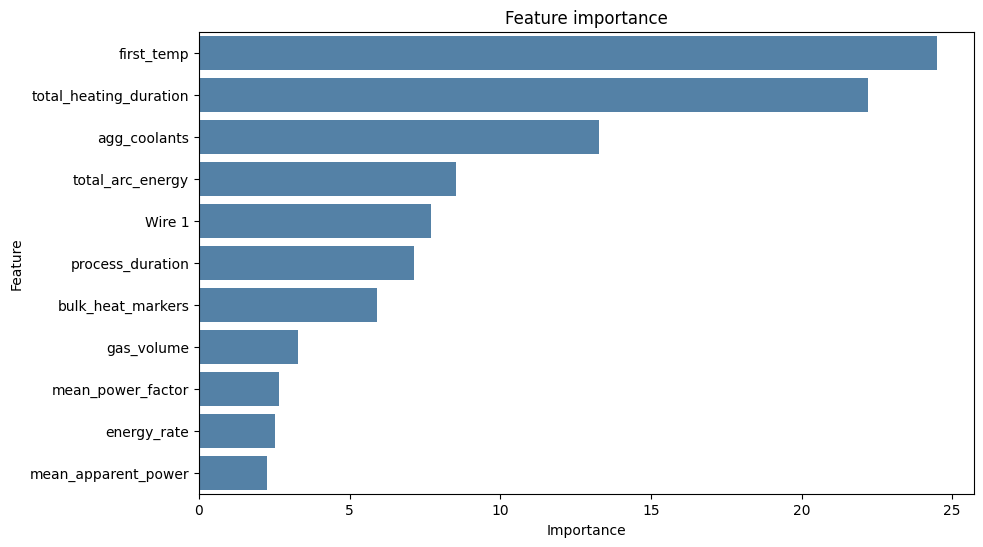


Топ-10 признаков:
                   feature  importance
0               first_temp   24.496160
2   total_heating_duration   22.197345
8             agg_coolants   13.270626
1         total_arc_energy    8.541957
3                   Wire 1    7.700171
5         process_duration    7.142679
7        bulk_heat_markers    5.921265
4               gas_volume    3.276584
10       mean_power_factor    2.672231
6              energy_rate    2.522229


In [145]:
print("Финальная модель CatBoost")

best_params = random_search.best_params_

# validation внутри train ( test независим)
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=30226
)

# Финальная модель с early stopping
final_model = CatBoostRegressor(
    iterations=5000,          # верхняя граница, определит early stopping
    early_stopping_rounds=200,
    od_type='Iter',          # остановка при отсутствии улучшений 
    loss_function='MAE',
    eval_metric='MAE',
    random_state=30226,
    verbose=0,
    **best_params
)

final_model.fit(
    X_train_final,
    y_train_final,
    eval_set=(X_val, y_val),   # validation для контроля обучения
    use_best_model=True        # сохраняется лучшая 
)

print(f"Best iteration: {final_model.best_iteration_}")  

#  проверка на test
final_pred = final_model.predict(X_test)
final_mae = mean_absolute_error(y_test, final_pred)

cv_mae = -random_search.best_score_

print(f"\nCV MAE: {cv_mae:.3f}")
print(f"Test MAE: {final_mae:.3f}")

gap = abs(final_mae - cv_mae)
print(f"Разрыв CV/Test: {gap:.3f}")  # индикатор переобучения 

if final_mae <= 6.8:
    print("Порог MAE выполнен")
else:
    print("MAE выше целевого")

if gap < 0.5:
    print("Модель стабильна")
else:
    print("Возможно переобучение")

# Feature importance (вклад признаков)
importances = final_model.get_feature_importance()
feature_names = X_train.columns

fi_df = (
    pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    })
    .sort_values(by='importance', ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    x='importance',
    y='feature',
    data=fi_df,
    color='steelblue'
)

plt.title('Feature importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

print("\nТоп-10 признаков:")
print(fi_df.head(10))

**Анализ результатов моделирования**.

Модель CatBoost продемонстрировала высокое качество и устойчивость: значение MAE на тестовой выборке составило 6.03, ниже установленного порога 6.8. Разрыв между кросс-валидацией и тестом (0.08) минимален, отсутствие признаков существенного переобучения.

Интерпретация факторов влияния (Feature Importance)

Физический базис.
Около 46% суммарной важности приходится на ключевые технологические признаки - first_temp (начальное состояние расплава) и total_heating_duration (длительность теплового воздействия). соответствует физике процесса: итоговая температура в первую очередь определяется стартовым теплосодержанием и объемом подведённой энергии.

Эффективность агрегированных признаков.
Признак agg_coolants (13%) входит в число наиболее значимых факторов. Это подтверждает гипотезу о том, что объединение добавок по их тепловому эффекту формирует более информативный сигнал для модели по сравнению с использованием отдельных разреженных признаков.

Технологические маркеры.
Высокая значимость Wire 1 и process_duration показывает, что модель учитывает как особенности легирования, так и теплопотери в ходе обработки партии. Дополнительный вклад энергетических параметров (total_arc_energy, energy_rate, mean_power_factor) указывает на важность режима нагрева при формировании итоговой температуры.

Вывод

Полученная модель является стабильной, объяснимой и соответствует заданным требованиям по точности. Результаты подтверждают применимость выбранного подхода для прогнозирования финальной температуры и создают основу для дальнейшего использования модели в задачах повышения управляемости процесса и потенциальной оптимизации энергопотребления.

In [146]:
# Сохранение модели и схемы

import joblib
from pathlib import Path

# Проверка: модель точно существует
assert 'final_model' in globals(), "Ошибка: final_model не определён"
assert hasattr(final_model, "predict"), "Ошибка: модель не обучена"

# Директория артефактов
ARTIFACTS_DIR = BASE_DIR / "artifacts"

if not ARTIFACTS_DIR.exists():
    ARTIFACTS_DIR.mkdir()

# Сохраняем модель
model_path = ARTIFACTS_DIR / "model.joblib"
joblib.dump(final_model, model_path)

print(f"Модель сохранена: {model_path}")

# Сохраняем порядок признаков (критично!)
EXPECTED_COLUMNS = list(X_train.columns)

columns_path = ARTIFACTS_DIR / "columns.txt"
with open(columns_path, "w") as f:
    for col in EXPECTED_COLUMNS:
        f.write(col + "\n")

print(f"Колонки сохранены: {columns_path}")

# Проверка
assert model_path.exists(), "Ошибка: модель не сохранилась"
assert columns_path.exists(), "Ошибка: columns.txt не создался"

Модель сохранена: C:\Users\79236\Desktop\Agri Ai\Металлургия\Metallurgy recommendation system\project\artifacts\model.joblib
Колонки сохранены: C:\Users\79236\Desktop\Agri Ai\Металлургия\Metallurgy recommendation system\project\artifacts\columns.txt


# **9. Итоговый отчёт** 

**Итоговый отчет по проекту**

**1. Выполненные этапы и преодоление трудностей**

В рамках проекта реализован полный цикл разработки ML-решения для предсказания температуры стали - от загрузки и очистки данных до обучения и финального тюнинга модели.

**Ключевые вызовы и решения**

**Проблема разреженности данных:**  
исходные таблицы присадок (`bulk`, `wire`) содержали большое количество пропусков и редких материалов.

**Решение:**  
применена стратегия агрегирования признаков. Добавки были объединены в группы по их тепловому влиянию - «маркеры нагрева» (положительная корреляция) и «охладители» (отрицательная корреляция). Это позволило сократить пространство признаков, снизить шум и уменьшить мультиколлинеарность.

**Проблема целостности данных:**  
существовал риск утечки данных (`data leakage`) из-за возможной рассинхронизации технологических событий.

**Решение:**  
проведена проверка утечки данных. Партии, в которых операции происходили после финального замера температуры, были исключены из анализа.

**2. Результаты моделирования**

Для сравнения использовались три модели:

- Ridge Regression  
- Random Forest  
- CatBoost  

**Лучшая модель:** CatBoostRegressor  

**Гиперпараметры (RandomizedSearchCV):**

- depth: 4  
- learning_rate: 0.05  
- l2_leaf_reg: 5  
- subsample: 0.8  
- iterations: до 5000 (с использованием early stopping)  
- оптимальная остановка обучения: 335 итераций  
- random_state: 30226  

**Метрики качества**

- **MAE на кросс-валидации:** 5.95  
- **MAE на тестовой выборке:** 6.03 (цель ≤ 6.8 достигнута)  

Разница между кросс валидацией и тестом составила 0.08°C, что указывает на устойчивость модели, без признаков выраженного переобучения.

**Сравнение с Baseline**

Baseline MAE = 8.20  

**Снижение ошибки:**  
8.20 – 6.03 = 2.17°C  

Относительное улучшение ,примерно 26%, что подтверждает практическую ценность модели.

**3. Ключевые факторы (Feature Importance)**

Модель опирается на физически интерпретируемые признаки, что снижает риск случайных зависимостей.

**Топ-5 факторов влияния:**

- **first_temp (24.5%)** - начальное тепловое состояние плавки.  
- **total_heating_duration (22.2%)** - суммарное время работы электродов.  
- **agg_coolants (13.3%)** -объем материалов с "охлаждающим" эффектом.  
- **total_arc_energy (8.5%)** - суммарная подведенная энергия.  
- **Wire 1 (7.7%)** - технологический маркер легирования.  

Набор ключевых признаков соответствует физике металлургического процесса, делает её интерпретируемой с инженерной точки зрения.

**4. Выводы и практическая значимость**

Разработанная модель предсказывает финальную температуру со средней ошибкой ±6.03°C, что соответствует бизнес-требованиям.

**Бизнес-эффект от внедрения**

- **Экономия электроэнергии** - снижение перегрева за счет более точного контроля нагрева.  
- **Оптимизация состава** - понимание влияния групп добавок на температурный режим.  
- **Стабильность качества** - уменьшение разброса температуры перед разливкой.  

**Рекомендация**

Использовать модель как систему поддержки принятия решений ("суфлёр") для оператора сталеплавильного агрегата. Это позволит прогнозировать температуру в процессе обработки и потенциально снизить удельный расход электроэнергии на тонну продукции.

In [147]:
from pathlib import Path
import joblib
import pandas as pd

print("=== PATH CHECK ===")

BASE_DIR = Path().resolve()
if BASE_DIR.name == "notebooks":
    BASE_DIR = BASE_DIR.parent

ARTIFACTS_DIR = BASE_DIR / "artifacts"
PROCESSED_DIR = BASE_DIR / "datasets" / "processed"

model_path = ARTIFACTS_DIR / "model.joblib"
columns_path = ARTIFACTS_DIR / "columns.txt"
data_path = PROCESSED_DIR / "processed_data.csv"

print("Artifacts:", ARTIFACTS_DIR)
print("Processed:", PROCESSED_DIR)

print("\n=== FILES EXIST ===")
print("model.joblib:", model_path.exists())
print("columns.txt:", columns_path.exists())
print("processed_data.csv:", data_path.exists())

print("\n=== MODEL LOAD TEST ===")
try:
    model = joblib.load(model_path)
    print("model loaded OK")
except Exception as e:
    print("model ERROR:", e)

print("\n=== COLUMNS CHECK ===")
try:
    with open(columns_path) as f:
        cols = [c.strip() for c in f.readlines()]
    print(f"columns loaded: {len(cols)} features")
except Exception as e:
    print("columns ERROR:", e)

print("\n=== DATA CHECK ===")
try:
    df = pd.read_csv(data_path)
    print("data shape:", df.shape)
except Exception as e:
    print("data ERROR:", e)

print("\n=== CONSISTENCY CHECK ===")
if 'cols' in locals() and 'df' in locals():
    missing = [c for c in cols if c not in df.columns]
    print("missing columns:", len(missing))
    if missing:
        print("пример:", missing[:5])

=== PATH CHECK ===
Artifacts: C:\Users\79236\Desktop\Agri Ai\Металлургия\Metallurgy recommendation system\project\artifacts
Processed: C:\Users\79236\Desktop\Agri Ai\Металлургия\Metallurgy recommendation system\project\datasets\processed

=== FILES EXIST ===
model.joblib: True
columns.txt: True
processed_data.csv: True

=== MODEL LOAD TEST ===
model loaded OK

=== COLUMNS CHECK ===
columns loaded: 11 features

=== DATA CHECK ===
data shape: (2328, 12)

=== CONSISTENCY CHECK ===
missing columns: 0
